# Chapter 13 — Deformation and Strain

**Strain is not a single number.** At any point in a loaded body, the complete state of deformation takes six independent components — three normal strains that stretch or compress, three shear strains that distort — bundled into a symmetric 3×3 tensor.

*Companion notebook to Chapter 13 — Deformation and Strain.*

This notebook works through two concrete demonstrations. The first derives the full strain field from a known displacement field — pure bending — and shows all three in-plane strain components as contour plots. The second examines *volumetric strain*: how the total change in volume relates to the sum of the normal strains, and why a material with ν = 0.5 is truly incompressible.

**This notebook demonstrates:**
1. The strain tensor computed from a pure-bending displacement field (contour plots of ε_xx, ε_yy, γ_xy)
2. Volumetric strain in uniaxial tension as a function of Poisson's ratio

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures generated here are written to the chapter's media folder.
OUT_DIR = Path("../src/media/ch13")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Strain Tensor from a Known Displacement Field

For pure bending, the displacement field is known analytically: the axial displacement u varies linearly with both position along the beam and distance from the neutral axis, while the transverse displacement v follows a parabolic form. Taking the spatial derivatives of this field gives the strain components directly. This is the connection strain measurement exploits in digital image correlation — surface displacements are differentiated to recover strain.

The contour plots show all three in-plane strain components over the beam cross-section. ε_xx is antisymmetric about the neutral axis (tension on one face, compression on the other). ε_yy is the Poisson response: the same sign pattern but scaled by −ν. γ_xy is identically zero for pure bending because no shear stress acts on horizontal planes. A surface strain gage on the outer fiber reads only ε_xx; recovering the full tensor requires a rosette.

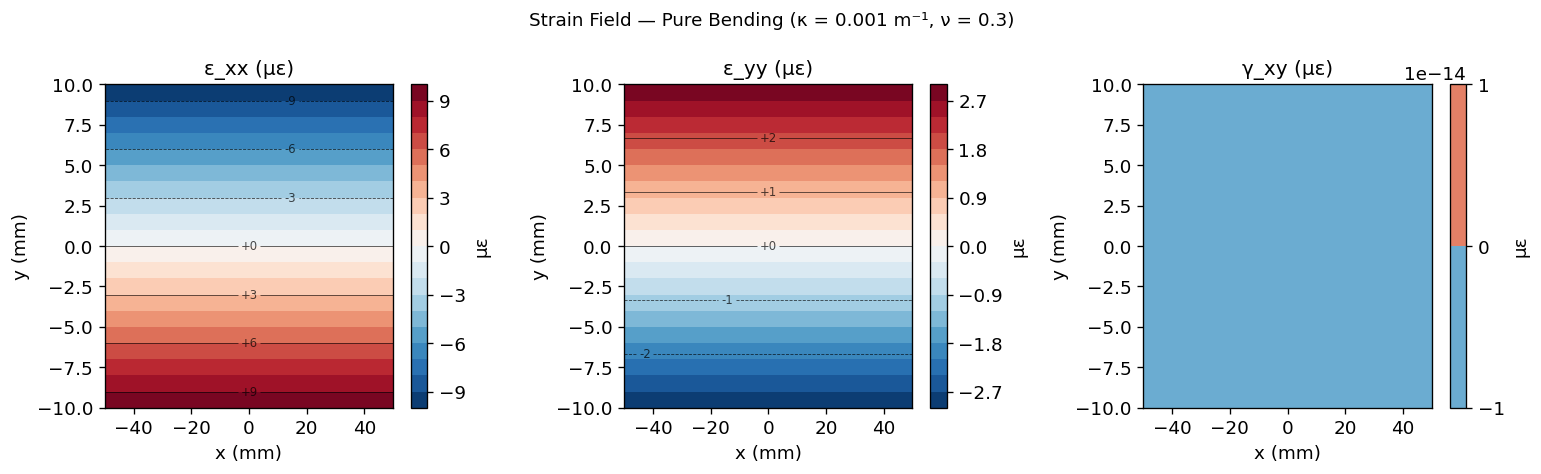

Max ε_xx at outer fiber (y = ±10 mm): 10 με


In [2]:
# Pure-bending displacement field (plane stress):
#     u(x, y) = -kappa * x * y
#     v(x, y) =  kappa/2 * (x**2 + nu * y**2)
# where kappa = curvature = M / (E*I). Differentiating this analytical field
# gives the strain components directly — the same operation digital image
# correlation performs numerically on measured surface displacements.

CURVATURE = 0.001          # kappa, beam curvature [1/m]
POISSON = 0.3              # nu, Poisson's ratio [-]
BEAM_HALF_LENGTH = 0.05    # x spans +/- this [m]
BEAM_HALF_HEIGHT = 0.01    # y spans +/- this; +/-HEIGHT are the outer fibers [m]
N_X, N_Y = 15, 10          # grid resolution in x and y


def bending_strains(kappa, nu, X, Y):
    """Return (eps_xx, eps_yy, gam_xy) for a pure-bending displacement field.

    Derived by differentiating u = -kappa*x*y, v = kappa/2*(x**2 + nu*y**2):
        eps_xx = du/dx        = -kappa * y
        eps_yy = dv/dy        =  kappa * nu * y   (Poisson response)
        gam_xy = du/dy + dv/dx = 0                (no shear in pure bending)
    """
    eps_xx = -kappa * Y
    eps_yy = kappa * nu * Y
    gam_xy = np.zeros_like(X)
    return eps_xx, eps_yy, gam_xy


x = np.linspace(-BEAM_HALF_LENGTH, BEAM_HALF_LENGTH, N_X)   # m
y = np.linspace(-BEAM_HALF_HEIGHT, BEAM_HALF_HEIGHT, N_Y)   # m
X, Y = np.meshgrid(x, y)

eps_xx, eps_yy, gam_xy = bending_strains(CURVATURE, POISSON, X, Y)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in zip(axes,
                           [eps_xx * 1e6, eps_yy * 1e6, gam_xy * 1e6],
                           ['ε_xx (με)', 'ε_yy (με)', 'γ_xy (με)']):
    im = ax.contourf(X * 1000, Y * 1000, data, levels=20, cmap='RdBu_r')
    # Labeled black contour lines keep sign + magnitude legible in grayscale /
    # B&W print, where the diverging red<->blue map collapses to similar greys.
    if np.ptp(data) > 1e-6:
        cs = ax.contour(X * 1000, Y * 1000, data, levels=6, colors='k',
                        linewidths=0.5, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=7, fmt='%+.0f')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='με')
fig.suptitle(f'Strain Field — Pure Bending (κ = {CURVATURE} m⁻¹, ν = {POISSON})',
             fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig13_nb1_strain_field_bending.png', bbox_inches='tight', dpi=150)
plt.show()

outer_fiber_strain = CURVATURE * BEAM_HALF_HEIGHT * 1e6
print(f"Max ε_xx at outer fiber (y = ±{BEAM_HALF_HEIGHT * 1000:.0f} mm): {outer_fiber_strain:.0f} με")

---
## 2 — Volumetric Strain and Dilatation

The trace of the strain tensor — ε_xx + ε_yy + ε_zz — is called the *dilatation* and equals the fractional change in volume. For a truly incompressible material (ν = 0.5), this sum is identically zero: any elongation in one direction is exactly cancelled by contractions in the other two. Real engineering metals have ν near 0.28–0.33, so roughly 35–45% of the axial elongation survives as a net volume increase.

This matters for strain gage practice when using surface measurements to back-calculate hydrostatic stress — a requirement in pressure vessel and geomechanics applications. The Poisson ratio you assume directly controls how much of the measured surface strain you attribute to volume change versus shape change.

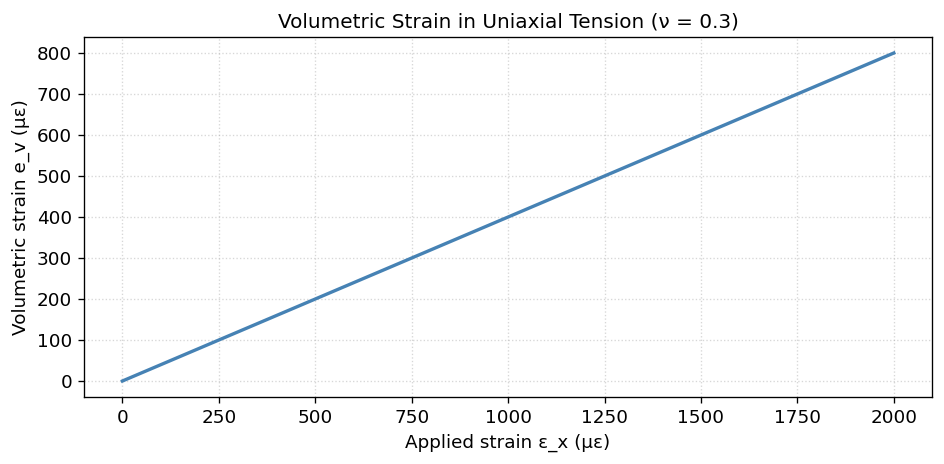

At ε_x = 1000 με: volumetric strain = 400 με
For ν = 0.5 (incompressible): volumetric strain = 0


In [3]:
# Volumetric strain (dilatation) = trace of the strain tensor = eps_xx + eps_yy + eps_zz.
# For a uniaxial STRESS state (sigma_x only): eps_yy = eps_zz = -nu*eps_xx, so
#     e_v = eps_axial * (1 - 2*nu).
# At nu = 0.5 the material is incompressible and e_v vanishes for any strain.

NU_STEEL = 0.3
MAX_STRAIN = 2000e-6       # sweep applied axial strain 0 -> 2000 microstrain [-]
N_POINTS = 200
REF_STRAIN = 1000e-6       # reference point reported below [-]


def volumetric_strain(eps_axial, nu):
    """Dilatation for a uniaxial stress state: e_v = eps_axial * (1 - 2*nu)."""
    return eps_axial * (1 - 2 * nu)


eps_x = np.linspace(0, MAX_STRAIN, N_POINTS)
ev = volumetric_strain(eps_x, NU_STEEL)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eps_x * 1e6, ev * 1e6, 'steelblue', lw=2)
ax.set_xlabel('Applied strain ε_x (με)')
ax.set_ylabel('Volumetric strain e_v (με)')
ax.set_title(f'Volumetric Strain in Uniaxial Tension (ν = {NU_STEEL})')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
# This figure is a notebook-only exploration; the book does not print it, so it is
# written to a local folder rather than into the book's media tree.
NB_ONLY_DIR = Path('figures/ch13')
NB_ONLY_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(NB_ONLY_DIR / 'volumetric_strain.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"At ε_x = {REF_STRAIN * 1e6:.0f} με: volumetric strain = {volumetric_strain(REF_STRAIN, NU_STEEL) * 1e6:.0f} με")
print("For ν = 0.5 (incompressible): volumetric strain = 0")

---
## Where to take this next

- **Feed in real DIC displacements.** Replace the analytical `u`, `v` with a measured (or synthetic + noisy) displacement field and recover the strains numerically with `np.gradient` instead of the closed-form derivatives. Compare the result against the analytical `−κy` to see how differentiation amplifies measurement noise — the central challenge of full-field strain mapping.
- **Break the zero-shear result.** Superpose a transverse-shear displacement field so that γ_xy is no longer identically zero, and watch the third contour panel come alive. This is the bridge to Chapter 18, where transverse shear in beams is measured directly with a rosette near the neutral axis.
- **Sweep Poisson's ratio in the dilatation plot.** Draw a family of e_v-versus-ε_x lines for ν = 0.0, 0.3, and 0.5 on one set of axes, then add an *auxetic* case (ν < 0) where the volume grows faster than the axial stretch alone — the negative-ν materials mentioned in the chapter.